In [1]:
import numpy as np
import numpy.random as npr
import matplotlib.pyplot as plt
import ssm

npr.seed(0)

c:\Users\Jasmine\miniconda3\envs\glmhmm\lib\importlib\_bootstrap.py:219: RuntimeWarning: numpy.ufunc size changed, may indicate binary incompatibility. Expected 192 from C header, got 216 from PyObject
  return f(*args, **kwds)
c:\Users\Jasmine\miniconda3\envs\glmhmm\lib\importlib\_bootstrap.py:219: RuntimeWarning: numpy.ufunc size changed, may indicate binary incompatibility. Expected 192 from C header, got 216 from PyObject
  return f(*args, **kwds)


In [189]:
# Set the parameters of the GLM-HMM
num_states = 2        # number of discrete states
obs_dim = 1           # number of observed dimensions
num_categories = 3    # number of categories for output
input_dim = 2         # input dimensions

# Make a GLM-HMM
true_glmhmm = ssm.HMM(num_states, obs_dim, input_dim, observations="input_driven_obs", 
                   observation_kwargs=dict(C=num_categories), transitions="standard")

# gen_weights = np.ones((num_states,num_categories,input_dim))
gen_weights = np.array([[[6, 1],[3, 4]], [[2, -3],[2, 3]]])#, [[2, 3]]])
# gen_log_trans_mat = np.log(np.array([[[0.8, 0.1, 0.1], [0.05, 0.92, 0.03], [0.01, 0.01, 0.98]]]))
gen_log_trans_mat = np.log(np.array([[[0.8, 0.2], [0.02, 0.98]]]))
true_glmhmm.observations.params = gen_weights
true_glmhmm.transitions.params = gen_log_trans_mat

In [190]:
# external input sequence
num_sess = 1 # 20 # number of example sessions
num_trials_per_sess = 2000 # 100 # number of trials in a session
inpts = np.ones((num_sess, num_trials_per_sess, input_dim)) # initialize inpts array
stim_vals = [-1, -0.5, -0.25, -0.125, -0.0625, 0, 0.0625, 0.125, 0.25, 0.5, 1]
inpts[:,:,0] = np.random.choice(stim_vals, (num_sess, num_trials_per_sess)) # generate random sequence of stimuli
inpts = list(inpts) #convert inpts to correct format

In [191]:
# Generate a sequence of latents and choices for each session
true_latents, true_choices = [], []
for sess in range(num_sess):
    true_z, true_y = true_glmhmm.sample(num_trials_per_sess, input=inpts[sess])
    true_latents.append(true_z)
    true_choices.append(true_y)
    
# Calculate true loglikelihood
true_ll = true_glmhmm.log_probability(true_choices, inputs=inpts) 
print("true ll = " + str(true_ll))

true ll = -669.8784636628955


In [192]:
new_glmhmm = ssm.HMM(num_states, obs_dim, input_dim, observations="input_driven_obs", 
                   observation_kwargs=dict(C=num_categories), transitions="standard")

N_iters = 200 # maximum number of EM iterations. Fitting with stop earlier if increase in LL is below tolerance specified by tolerance parameter
fit_ll = new_glmhmm.fit(true_choices, inputs=inpts, method="em", num_iters=N_iters, tolerance=10**-4)
# from ssm.util import find_permutation
# new_glmhmm.permute(find_permutation(true_latents, new_glmhmm.most_likely_states(true_choices, input=inpts)))

  0%|          | 0/200 [00:00<?, ?it/s]

In [193]:
posterior_probs = [new_glmhmm.expected_states(data=data, input=inpt)[0]
                for data, inpt
                in zip(true_choices, inpts)]
# concatenate posterior probabilities across sessions
posterior_probs_concat = np.concatenate(posterior_probs)
# get state with maximum posterior probability at particular trial:
state_pred = np.argmax(posterior_probs_concat, axis = 1)

In [196]:
np.unique(pred_choices)

array([0, 1, 2])

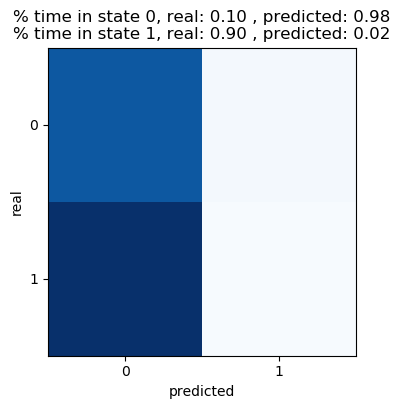

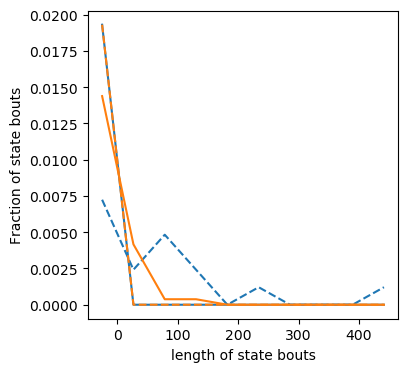

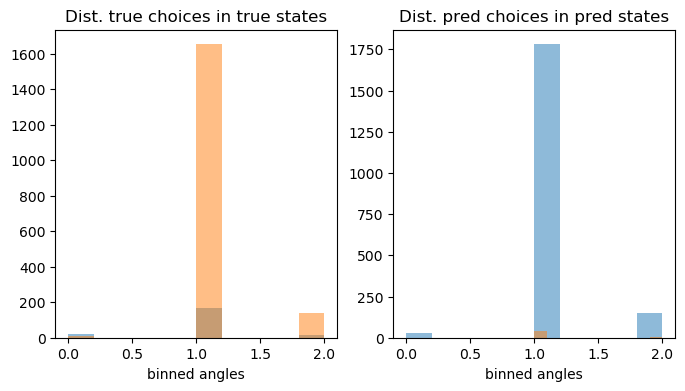

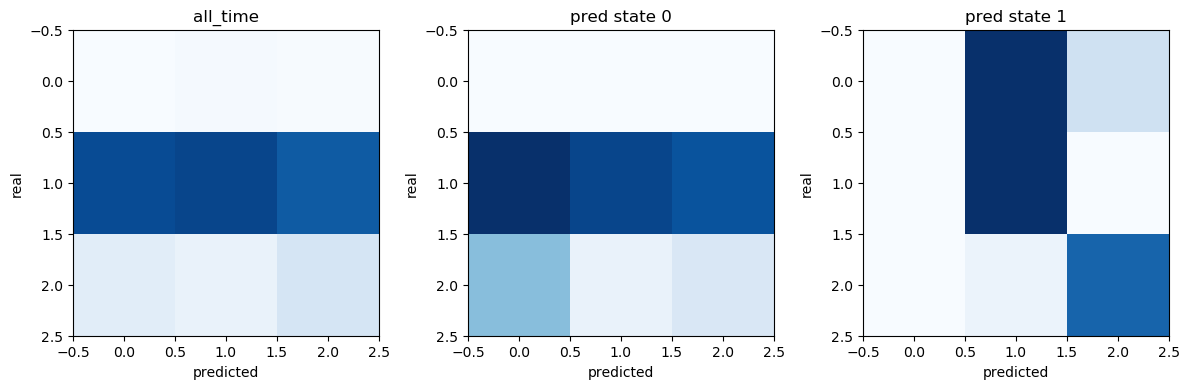

In [194]:
"""How well did it guess the state at each time?"""
# state_pred = new_glmhmm.most_likely_states(true_choices, input=inpts)

from sklearn.metrics import confusion_matrix
true_state = np.concatenate(true_latents)
conf = confusion_matrix(true_state, state_pred)
conf = conf.astype("float64")
conf = conf / np.sum(conf, axis=1)

fig, axs = plt.subplots(1,1,figsize = (4,4))
axs.imshow(conf, cmap="Blues", vmin=0, vmax=1)
axs.set_ylabel("real")
axs.set_xlabel("predicted")
axs.set_xticks(np.arange(num_states))
axs.set_yticks(np.arange(num_states))
axs.set_title('% time in state 0, real: ' + "%.2f" % (np.sum(true_state == 0)/len(true_state)) +' , predicted: ' + "%.2f" % (np.sum(state_pred == 0)/len(state_pred)) +
              '\n% time in state 1, real: ' + "%.2f" % (np.sum(true_state == 1)/len(true_state)) +' , predicted: ' + "%.2f" % (np.sum(state_pred == 1)/len(state_pred)))


"""How long does each state bout last?"""

real_time = []
for i in np.arange(num_states):
    st = (true_state == i).astype(int)
    if st[0] == 1:
        st = np.hstack((np.zeros(1),st))
    if st[-1] == 1:
        st = np.hstack((st,np.zeros(1)))
    start = np.where(np.diff(st) == 1)[0]
    end = np.where(np.diff(st) == -1)[0]
    real_time.append(np.abs(start - end))

pred_time = []
for i in np.arange(num_states):
    st = (state_pred == i).astype(int)
    if st[0] == 1:
        st = np.hstack((np.zeros(1),st))
    if st[-1] == 1:
        st = np.hstack((st,np.zeros(1)))
    start = np.where(np.diff(st) == 1)[0]
    end = np.where(np.diff(st) == -1)[0]
    pred_time.append(np.abs(start - end))

longest = np.amax(np.append(np.concatenate(pred_time), np.concatenate(real_time)))
shortest = np.amin(np.append(np.concatenate(pred_time), np.concatenate(real_time)))

fig, axs = plt.subplots(1,1,figsize = (4,4))
colorz = plt.rcParams['axes.prop_cycle'].by_key()['color']
for i in np.arange(num_states):
    # real
    h, b = np.histogram(real_time[i],range = (shortest,longest), density = True)
    bc = b[:-1]-np.mean(np.diff(b))/2
    axs.plot(bc,h, '-', color = colorz[i])
    # pred
    h, b = np.histogram(pred_time[i],range = (shortest,longest), density = True)
    bc = b[:-1]-np.mean(np.diff(b))/2
    axs.plot(bc,h, '--', color = colorz[i])

axs.set_xlabel('length of state bouts')
axs.set_ylabel('Fraction of state bouts')

"""Distribution of values in the two states"""
pred_latents, pred_output = [], []
for sess in range(num_sess):
    pred_z, pred_y = new_glmhmm.sample(num_trials_per_sess, input=inpts[sess])
    pred_latents.append(pred_z)
    pred_output.append(pred_y)

pred_choices = np.concatenate(pred_output)
true_output = np.concatenate(true_choices)
fig, axs = plt.subplots(1,2,figsize = (8,4))
for i in np.arange(num_states):
    axs[0].hist(true_output[true_state == i], alpha = .5, color = colorz[i])
axs[0].set_title('Dist. true choices in true states')
axs[0].set_xlabel('binned angles')

for i in np.arange(num_states):
    axs[1].hist(pred_choices[state_pred == i], alpha = .5, color = colorz[i])
axs[1].set_title('Dist. pred choices in pred states')
axs[1].set_xlabel('binned angles')

"""Based on the inputs, what does it think the angles should be?"""
conf = confusion_matrix(true_output, pred_choices)
conf = conf.astype("float64")
conf = conf / np.sum(conf, axis=1)

fig, axs = plt.subplots(1,3,figsize = (12,4))
axs[0].imshow(conf, cmap="Blues", vmin=0, vmax=1)
axs[0].set_ylabel("real")
axs[0].set_xlabel("predicted")
axs[0].set_title("all_time")

conf = confusion_matrix(true_output[state_pred == 0], pred_choices[state_pred == 0])
conf = conf.astype("float64")
conf = conf / np.sum(conf, axis=1)
axs[1].imshow(conf, cmap="Blues", vmin=0, vmax=1)
axs[1].set_ylabel("real")
axs[1].set_xlabel("predicted")
axs[1].set_title("pred state 0")

conf = confusion_matrix(true_output[state_pred == 1], pred_choices[state_pred == 1])
conf = conf.astype("float64")
conf = conf / np.sum(conf, axis=1)
axs[2].imshow(conf, cmap="Blues", vmin=0, vmax=1)
axs[2].set_ylabel("real")
axs[2].set_xlabel("predicted")
axs[2].set_title("pred state 1")
plt.tight_layout()

Trying Ashwood generative method for hdir data

In [160]:
# Set the parameters of the GLM-HMM
num_states = 2        # number of discrete states
obs_dim = 1           # number of observed dimensions
num_categories = 12    # number of categories for output
input_dim = 6         # input dimensions

# Make a GLM-HMM
true_glmhmm = ssm.HMM(num_states, obs_dim, input_dim, observations="input_driven_obs", 
                   observation_kwargs=dict(C=num_categories), transitions="standard")

gen_weights = np.ones((num_states,num_categories-1,input_dim)) # np.array([[[6, 1]], [[2, -3]]])

for i in np.arange(input_dim):
    data = np.random.normal(loc = 0, scale = 1, size = np.random.randint(100,200,1))
    hist, bins = np.histogram(data, bins = num_categories - 1)
    weights = [np.roll(hist,np.random.randint(0,num_categories - 1,1))]
    weights = weights / np.amax(weights)
    for j in np.arange(num_states):
        gen_weights[j,:,i] = weights*np.abs(np.random.normal(size = 1))

gen_weights = np.array(gen_weights)

gen_log_trans_mat = np.log(np.array([[[0.98, 0.01], [0.08, 0.92]]]))
true_glmhmm.observations.params = gen_weights
true_glmhmm.transitions.params = gen_log_trans_mat

In [171]:
# external input sequence
num_sess = 1 # 20 # number of example sessions
num_trials_per_sess = 100000 # number of trials in a session
inpts = np.ones((num_sess, num_trials_per_sess, input_dim)) # initialize inpts array
stim_range = [[20,80],[8,15],[30,100],[0,20],[5,50],[40,80]]
for i in np.arange(input_dim):
    inpts[:,:,i] = np.random.randint(stim_range[i][0], stim_range[i][1], (num_trials_per_sess)) # generate random sequence of stimuli
inpts = list(inpts) #convert inpts to correct format

In [172]:
# Generate a sequence of latents and choices for each session
true_latents, true_choices = true_glmhmm.sample(num_trials_per_sess, input=inpts[0])
    
# Calculate true loglikelihood
true_ll = true_glmhmm.log_probability(true_choices, inputs=inpts) 
print("true ll = " + str(true_ll))

true ll = -13574.119231665187


Text(0.5, 1.0, 'weights per category in the two states')

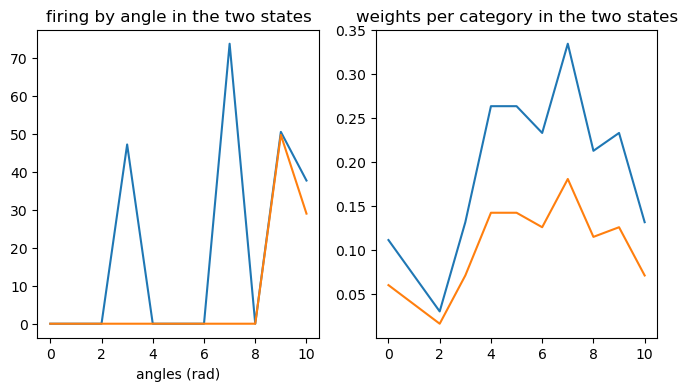

In [173]:
def firing_by_angle_bin(angles, neural_activity, nbins):
    angles_firing = np.zeros(nbins - 1)
    unique_groups, group_counts = np.unique(angles, return_counts=True)
    group_sums = np.bincount(angles, weights=neural_activity)
    angles_firing[unique_groups] = group_sums[unique_groups] / group_counts
    return angles_firing

idx = 0
fig,ax = plt.subplots(1,2,figsize = (8,4))
ax[0].plot(firing_by_angle_bin(true_choices[true_latents == 0,0],inpts[0][true_latents == 0,idx], 12))
ax[0].plot(firing_by_angle_bin(true_choices[true_latents == 1,0],inpts[0][true_latents == 1,idx], 12))
ax[0].set_title("firing by angle in the two states")
ax[0].set_xlabel('angles (rad)')

ax[1].plot(true_glmhmm.observations.Wk[0,:,idx])
ax[1].plot(true_glmhmm.observations.Wk[1,:,idx])
ax[1].set_title("weights per category in the two states")

In [ ]:
new_glmhmm = ssm.HMM(num_states, obs_dim, input_dim, observations="input_driven_obs", 
                   observation_kwargs=dict(C=num_categories), transitions="standard")

N_iters = 100 # maximum number of EM iterations. Fitting with stop earlier if increase in LL is below tolerance specified by tolerance parameter
fit_ll = new_glmhmm.fit(true_choices, inputs=inpts, method="em", num_iters=N_iters, tolerance=10**-4)

In [ ]:
"""How well did it guess the state at each time?"""
# state_pred = new_glmhmm.most_likely_states(true_choices, input=inpts)

from sklearn.metrics import confusion_matrix
true_state = np.concatenate(true_latents)
conf = confusion_matrix(true_state, state_pred)
conf = conf.astype("float64")
conf = conf / np.sum(conf, axis=1)

fig, axs = plt.subplots(1,1,figsize = (4,4))
axs.imshow(conf, cmap="Blues", vmin=0, vmax=1)
axs.set_ylabel("real")
axs.set_xlabel("predicted")
axs.set_xticks(np.arange(num_states))
axs.set_yticks(np.arange(num_states))
axs.set_title('% time in state 0, real: ' + "%.2f" % (np.sum(true_state == 0)/len(true_state)) +' , predicted: ' + "%.2f" % (np.sum(state_pred == 0)/len(state_pred)) +
              '\n% time in state 1, real: ' + "%.2f" % (np.sum(true_state == 1)/len(true_state)) +' , predicted: ' + "%.2f" % (np.sum(state_pred == 1)/len(state_pred)))


"""How long does each state bout last?"""

real_time = []
for i in np.arange(num_states):
    st = (true_state == i).astype(int)
    if st[0] == 1:
        st = np.hstack((np.zeros(1),st))
    if st[-1] == 1:
        st = np.hstack((st,np.zeros(1)))
    start = np.where(np.diff(st) == 1)[0]
    end = np.where(np.diff(st) == -1)[0]
    real_time.append(np.abs(start - end))


pred_time = []
for i in np.arange(num_states):
    st = (state_pred == i).astype(int)
    if st[0] == 1:
        st = np.hstack((np.zeros(1),st))
    if st[-1] == 1:
        st = np.hstack((st,np.zeros(1)))
    start = np.where(np.diff(st) == 1)[0]
    end = np.where(np.diff(st) == -1)[0]
    pred_time.append(np.abs(start - end))

longest = np.amax(np.append(np.concatenate(pred_time), np.concatenate(real_time)))
shortest = np.amin(np.append(np.concatenate(pred_time), np.concatenate(real_time)))

fig, axs = plt.subplots(1,1,figsize = (4,4))
colorz = plt.rcParams['axes.prop_cycle'].by_key()['color']
for i in np.arange(num_states):
    # real
    h, b = np.histogram(real_time[i],range = (shortest,longest), density = True)
    bc = b[:-1]-np.mean(np.diff(b))/2
    axs.plot(bc,h, '-', color = colorz[i])
    # pred
    h, b = np.histogram(pred_time[i],range = (shortest,longest), density = True)
    bc = b[:-1]-np.mean(np.diff(b))/2
    axs.plot(bc,h, '--', color = colorz[i])

axs.set_xlabel('length of state bouts')
axs.set_ylabel('Fraction of state bouts')

"""Distribution of values in the two states"""
pred_latents, pred_output = [], []
for sess in range(num_sess):
    pred_z, pred_y = new_glmhmm.sample(num_trials_per_sess, input=inpts[sess])
    pred_latents.append(pred_z)
    pred_output.append(pred_y)

pred_choices = np.concatenate(pred_output)
true_output = np.concatenate(true_choices)
fig, axs = plt.subplots(1,2,figsize = (8,4))
for i in np.arange(num_states):
    axs[0].hist(true_output[true_state == i], alpha = .5, color = colorz[i])
axs[0].set_title('Dist. true choices in true states')
axs[0].set_xlabel('binned angles')

for i in np.arange(num_states):
    axs[1].hist(pred_choices[state_pred == i], alpha = .5, color = colorz[i])
axs[1].set_title('Dist. pred choices in pred states')
axs[1].set_xlabel('binned angles')

"""Based on the inputs, what does it think the angles should be?"""
conf = confusion_matrix(true_output, pred_choices)
conf = conf.astype("float64")
conf = conf / np.sum(conf, axis=1)

fig, axs = plt.subplots(1,3,figsize = (12,4))
axs[0].imshow(conf, cmap="Blues", vmin=0, vmax=1)
axs[0].set_ylabel("real")
axs[0].set_xlabel("predicted")
axs[0].set_title("all_time")

conf = confusion_matrix(true_output[state_pred == 0], pred_choices[state_pred == 0])
conf = conf.astype("float64")
conf = conf / np.sum(conf, axis=1)
axs[1].imshow(conf, cmap="Blues", vmin=0, vmax=1)
axs[1].set_ylabel("real")
axs[1].set_xlabel("predicted")
axs[1].set_title("pred state 0")

conf = confusion_matrix(true_output[state_pred == 1], pred_choices[state_pred == 1])
conf = conf.astype("float64")
conf = conf / np.sum(conf, axis=1)
axs[2].imshow(conf, cmap="Blues", vmin=0, vmax=1)
axs[2].set_ylabel("real")
axs[2].set_xlabel("predicted")
axs[2].set_title("pred state 1")
plt.tight_layout()